## Basic data analysis using python

In [23]:
import pandas as pd

df = pd.read_csv("customer_shopping_behavior_raw_file.csv")

In [24]:
print("First 5 rows", df.head(), "\n")
print("Last 5 rows", df.tail())

First 5 rows    Customer ID  Age Gender Item Purchased  Category  Purchase Amount (USD)  \
0            1   55   Male         Blouse  Clothing                     53   
1            2   19   Male        Sweater  Clothing                     64   
2            3   50   Male          Jeans  Clothing                     73   
3            4   21   Male        Sandals  Footwear                     90   
4            5   45   Male         Blouse  Clothing                     49   

        Location Size      Color  Season  Review Rating Subscription Status  \
0       Kentucky    L       Gray  Winter            3.1                 Yes   
1          Maine    L     Maroon  Winter            3.1                 Yes   
2  Massachusetts    S     Maroon  Spring            3.1                 Yes   
3   Rhode Island    M     Maroon  Spring            3.5                 Yes   
4         Oregon    M  Turquoise  Spring            2.7                 Yes   

   Shipping Type Discount Applied Promo Cod

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   customer_id              3900 non-null   int64   
 1   age                      3900 non-null   int64   
 2   gender                   3900 non-null   object  
 3   item_purchased           3900 non-null   object  
 4   category                 3900 non-null   object  
 5   purchased_amount         3900 non-null   int64   
 6   location                 3900 non-null   object  
 7   size                     3900 non-null   object  
 8   color                    3900 non-null   object  
 9   season                   3900 non-null   object  
 10  review_rating            3900 non-null   float64 
 11  subscription_status      3900 non-null   object  
 12  shipping_type            3900 non-null   object  
 13  discount_applied         3900 non-null   object  
 14  previous

In [26]:
# statistical summary of the dataset
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3863.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.750065,25.351538
std,1125.977353,15.207589,23.685392,0.716983,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.800000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [27]:
df.isnull().sum()

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

Data distribution of Review Rating Column


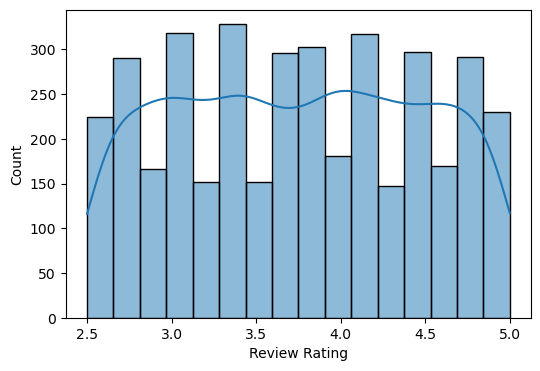

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize = (6, 4))
sns.histplot(df['Review Rating'], kde = True)
print("Data distribution of Review Rating Column")
plt.show()

In [29]:
# converting column names into snakecase letters
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(' ', '_')
df = df.rename(columns = {'purchase_amount_(usd)' : 'purchased_amount'})
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchased_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases'],
      dtype='object')

In [30]:
df['review_rating'] = df.groupby('category')['review_rating'].transform(lambda x: x.fillna(x.median()))
df.isnull().sum()  

customer_id               0
age                       0
gender                    0
item_purchased            0
category                  0
purchased_amount          0
location                  0
size                      0
color                     0
season                    0
review_rating             0
subscription_status       0
shipping_type             0
discount_applied          0
promo_code_used           0
previous_purchases        0
payment_method            0
frequency_of_purchases    0
dtype: int64

In [31]:
labels = ['young adult', 'adult', 'middle aged', 'senior']
df['age_group'] = pd.qcut(df['age'], q = 4, labels = labels)
df[['age', 'age_group']].head()

,age,age_group
0,55,middle aged
1,19,young adult
2,50,middle aged
3,21,young adult
4,45,middle aged


In [32]:
df[df['discount_applied'] == df['promo_code_used']].shape
df.shape

# df[df['discount_applied'] == df['promo_code_used']].shape == df.shape

(3900, 19)

In [33]:
df.drop("promo_code_used", axis = 1, inplace = True)
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchased_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'previous_purchases', 'payment_method',
       'frequency_of_purchases', 'age_group'],
      dtype='object')

In [34]:
frequency_list = df['frequency_of_purchases'].unique()
freq_map = {
    'Fortnightly': 14,
    'Weekly': 7,
    'Annually': 365,
    'Quarterly': 90,
    'Bi-Weekly': 14,
    'Monthly': 30,
    'Every 3 Months': 90
}
df['purchase_frequency_days'] = df['frequency_of_purchases'].map(freq_map)

In [36]:
df[['purchase_frequency_days', 'frequency_of_purchases']].head()

,purchase_frequency_days,frequency_of_purchases
0,14,Fortnightly
1,14,Fortnightly
2,7,Weekly
3,7,Weekly
4,365,Annually


# Connecting Python script to PostgreSQL

In [37]:
!pip install psycopg2-binary sqlalchemy

In [41]:
from sqlalchemy import create_engine

# Step 1: Connect to PostgreSQL
username = "postgres"      
password = "passwordpgAdmin" 
host = "localhost"         
port = "5432"
database = "customer_behavior"    

engine = create_engine(f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}")

# Step 2: Load DataFrame into PostgreSQL
table_name = "customer" 
df.to_sql(table_name, engine, if_exists="replace", index=False)

print(f"Data successfully loaded into table '{table_name}' in database '{database}'.")

Data successfully loaded into table 'customer' in database 'customer_behavior'.
